In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [15]:
df = pd.read_csv(
    '../data/processed/cleaned_marketing.csv'
)

In [16]:
df['date'] = pd.to_datetime(df['date'])

In [17]:
purchase_mean = df['purchase'].mean()

purchase_std = df['purchase'].std()

n = len(df)

print("Mean:", purchase_mean)

print("Standard Deviation:", purchase_std)

print("Sample Size:", n)

Mean: 522.0
Standard Deviation: 196.97391740515047
Sample Size: 60


In [18]:
standard_error = purchase_std / np.sqrt(n)

print("Standard Error:", standard_error)

Standard Error: 25.429223391579434


In [19]:
margin_error = 1.96 * standard_error

lower_bound = purchase_mean - margin_error

upper_bound = purchase_mean + margin_error

print("95% Confidence Interval:")

print(lower_bound, upper_bound)

95% Confidence Interval:
472.1587221525043 571.8412778474957


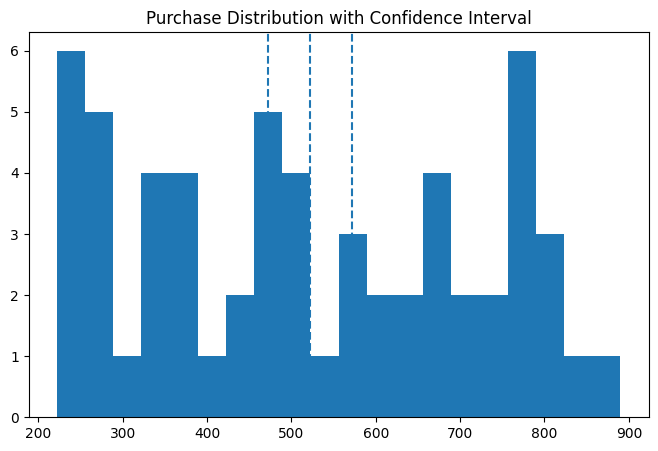

In [20]:
plt.figure(figsize=(8,5))

plt.hist(
    df['purchase'],
    bins=20
)

plt.axvline(
    purchase_mean,
    linestyle='--'
)

plt.axvline(
    lower_bound,
    linestyle='--'
)

plt.axvline(
    upper_bound,
    linestyle='--'
)

plt.title('Purchase Distribution with Confidence Interval')

plt.show()

In [21]:
control = df[df['group']=='control']

test = df[df['group']=='test']

In [22]:
control_mean = control['purchase'].mean()

control_std = control['purchase'].std()

control_n = len(control)

control_se = control_std / np.sqrt(control_n)

control_ci = 1.96 * control_se

print(
    control_mean - control_ci,
    control_mean + control_ci
)

456.5814540999528 589.0047527965988


In [23]:
test_mean = test['purchase'].mean()

test_std = test['purchase'].std()

test_n = len(test)

test_se = test_std / np.sqrt(test_n)

test_ci = 1.96 * test_se

print (
    test_mean - test_ci,
    test_mean + test_ci
)

445.71086779099375 596.7557988756729


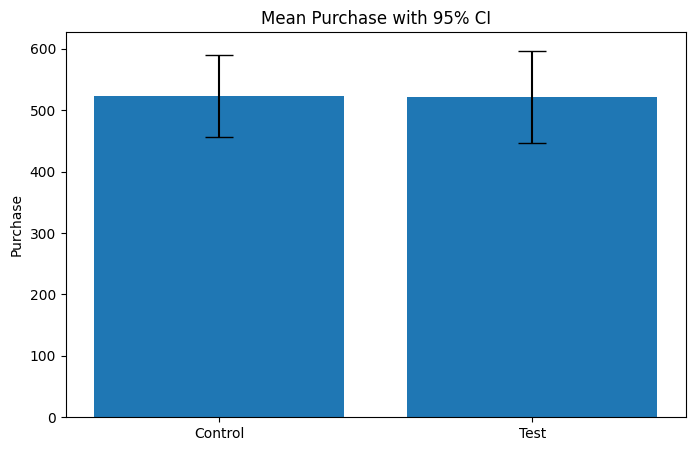

In [24]:
means = [
    control_mean,
    test_mean
]

errors = [
    control_ci,
    test_ci
]

groups = [
    'Control',
    'Test'
]

plt.figure(figsize=(8,5))

plt.bar(
    groups,
    means,
    yerr=errors,
    capsize=10
)

plt.title(
    'Mean Purchase with 95% CI'
)

plt.ylabel('Purchase')

plt.show()

# CONFIDENCE INTERVAL INTERPRETATION

The confidence interval was used to estimate the plausible range of the population mean purchase value.

A 95% confidence interval indicates that if the experiment were repeated many times, approximately 95% of the calculated intervals would contain the true population mean.

The confidence interval also provides insight into the uncertainty of the estimate. A narrower interval indicates more stable and reliable estimates, while a wider interval suggests higher variability in the data.

